## Токенизация

Мы хотим, чтобы компьютер не просто тупо хранил текст, а понимал его: мог перевести на другой язык, ответить на вопрос, определить тональность письма или даже написать стихотворение. Чтобы это стало возможным, мы должны превратить текст в то, в чём компьютер разбирается лучше всего, - в числа. Причём не в любые числа, а в такие, которые несут в себе смысл слов, их связи и отношения.

Это и есть задача векторных **представлений слов (word embeddings)**. Идея гениально проста: каждое слово можно представить как точку в многомерном пространстве. Хорошо обученное пространство устроено так, что слова со схожим значением (например, «кот» и «кошка») оказываются рядом, а слова с разным значением («кот» и «атомный реактор») - далеко.

Но как перейти от простого текста к этим волшебным векторам? Просто взять и присвоить каждому слову случайный номер (как в телефонной книге) нельзя: числа 45 для «кота» и 890 для «сметаны» ничего не говорят об их отношениях. Нам нужен сложный, многоступенчатый процесс, который превращает сырой текст в структурированные числовые данные, готовые к подаче в нейронную сеть.

### Первый этап самый интуитивный.

Представьте, что вы учите иностранный язык. Вы берете книгу и хотите перевести каждое слово. Но компьютер не понимает слова так, как мы. Для него любой текст - это просто последовательность символов. Чтобы машина могла работать с текстом, его нужно превратить в числа. Этот процесс называется **токенизацией (tokenization)** - разбиение текста на маленькие кусочки - токены - и присвоение каждому токену уникального числового **идентификатора (далее - ID)**.

Токен - это не всегда слово. Это может быть часть слова или даже знак препинания. Главное правило: нам нужно найти золотую середину. Если делать токенами целые слова, словарь получится огромным (ведь есть ещё «Кота», «Коту», «Котом»). Если делать токенами буквы - мы потеряем смысл связки букв.

В современных моделях используется компромисс: текст режут на кусочки где-то между буквой и словом.

Рассмотрим пример:
Исходный текст: `"Кот любит сметану"`

Допустим, наш токенизатор сработал так:

1. `Кот`

2. `Пробел`

3. `любит`

4. `Пробел`

5. `сметану`



В реальности, если бы у нас был словарь редко встречающихся слов, слово `"сметану"` могли бы разбить на `[сметан]` и `[у]`, чтобы не хранить все падежи отдельно. Но для простоты примера оставим как есть.

Результат: получаем список `['Кот',' ', 'любит',' ', 'сметану']`.

Далее создадим псевдословарь, в котором каждому слову и знаку препинания будет соответствовать определённое число.

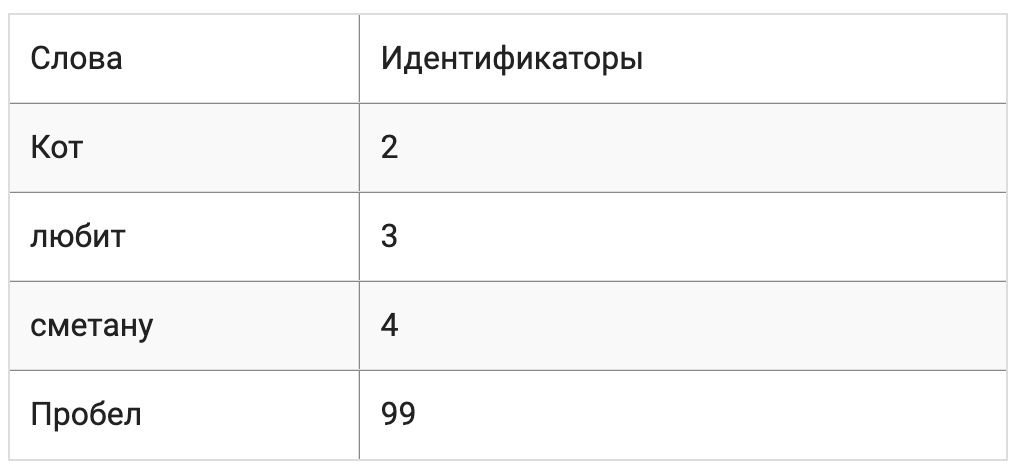

**Результат:** получаем список идентификаторов [2,99,3,99,4]. Вот теперь, у нас есть цифры, а не слова.

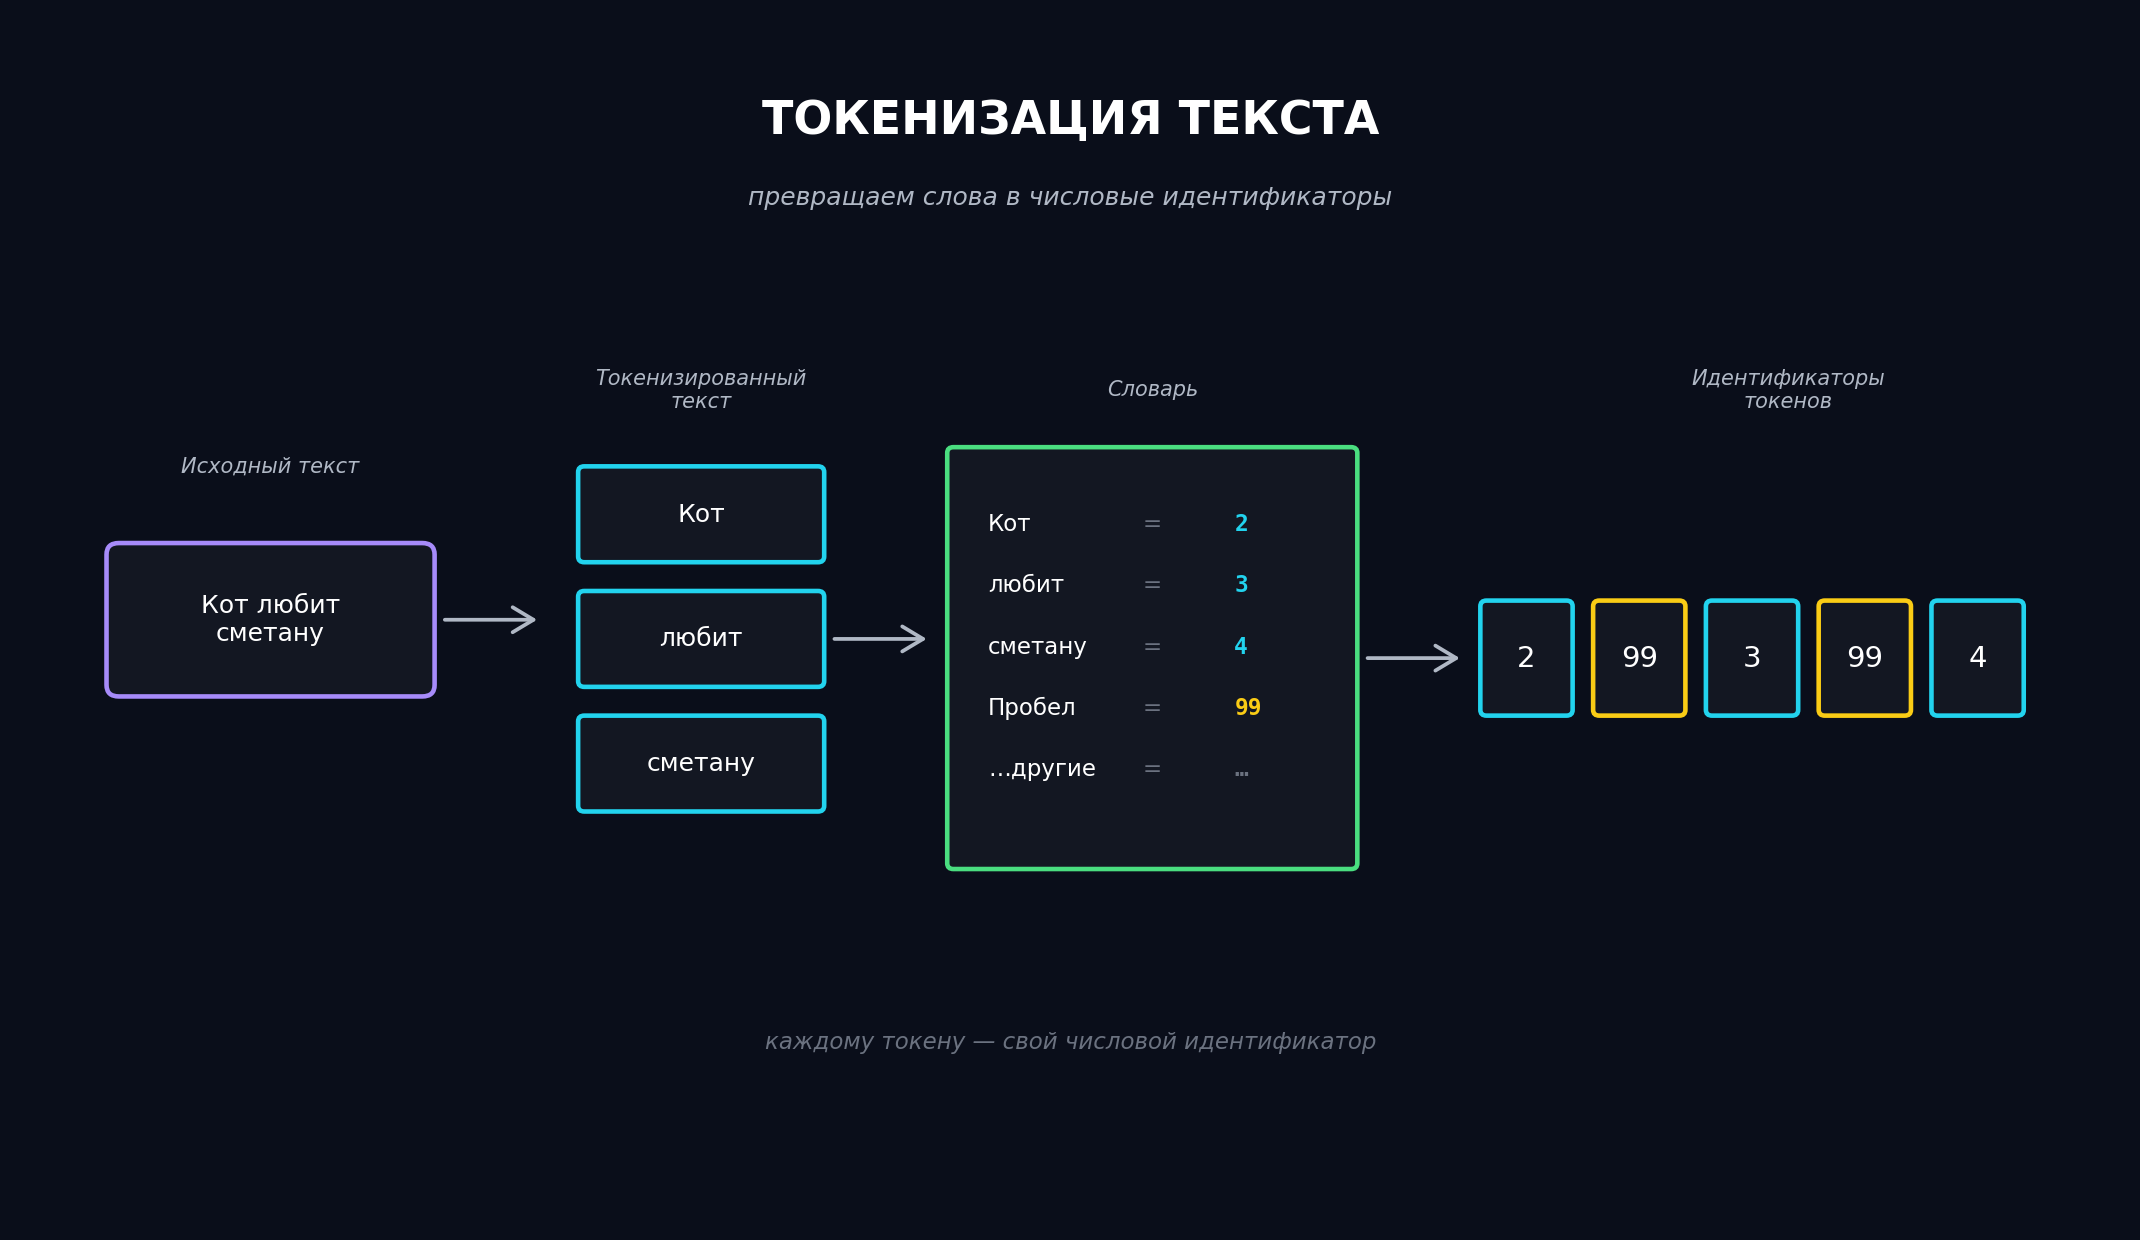

## Когда токенов нет в словаре

А что произойдёт, если мы встретим текст со словом, который отсутствует в нашем словаре?

Например, предложение:

`Кот любит сметану -> Кот очень любит свежую сметану`

Здесь есть новые слова "очень" и "свежую", которых в нашем словаре нет. Если мы попытаемся преобразовать этот текст в идентификаторы, по нашему словарю, мы не найдём для них соответствия. И токенизатор **«упадет» с ошибкой**.

Это классическая проблема `Out-of-Vocabulary (OOV)`.



Давайте подумаем, как можно решить данную проблему. Например, можно заранее создать универсальный словарь, включающий все буквы алфавитов, цифры, знаки препинания и т.д. Например, взять таблицу Unicode. Но тогда словарь станет огромным (более 100 000 символов), и большинство из них никогда не встретятся. Это неэффективно.

Самый распространённый способ - ввести специальный токен, обозначающий неизвестный символ (unknown). Обычно его называют `[UNK]` или `<unk>`. Мы добавляем его в словарь и присваиваем ему отдельный ID. Тогда при обработке нового текста все новые слова, которых нет в словаре, заменяются на `[UNK]`.

Добавим в наш словарь токен `[UNK]`:

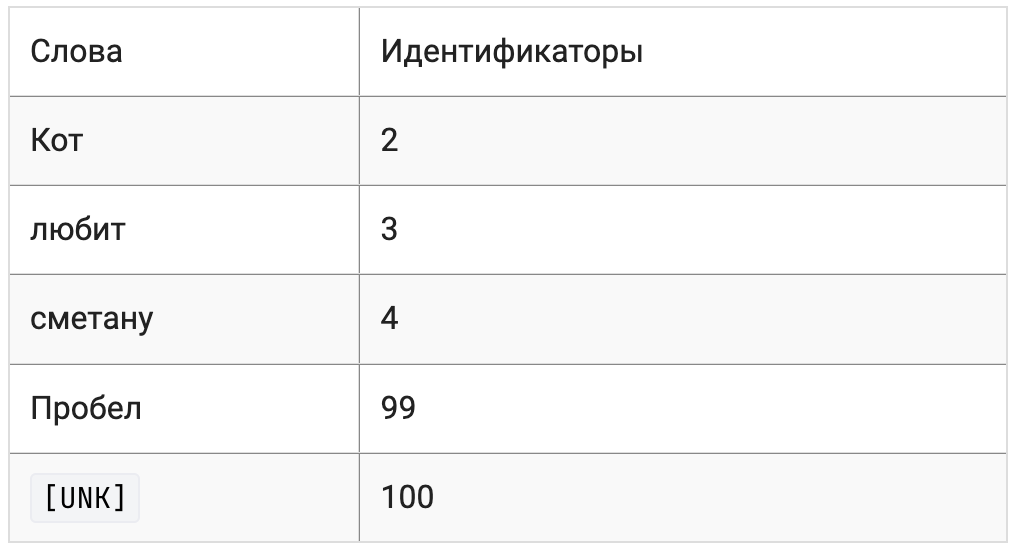

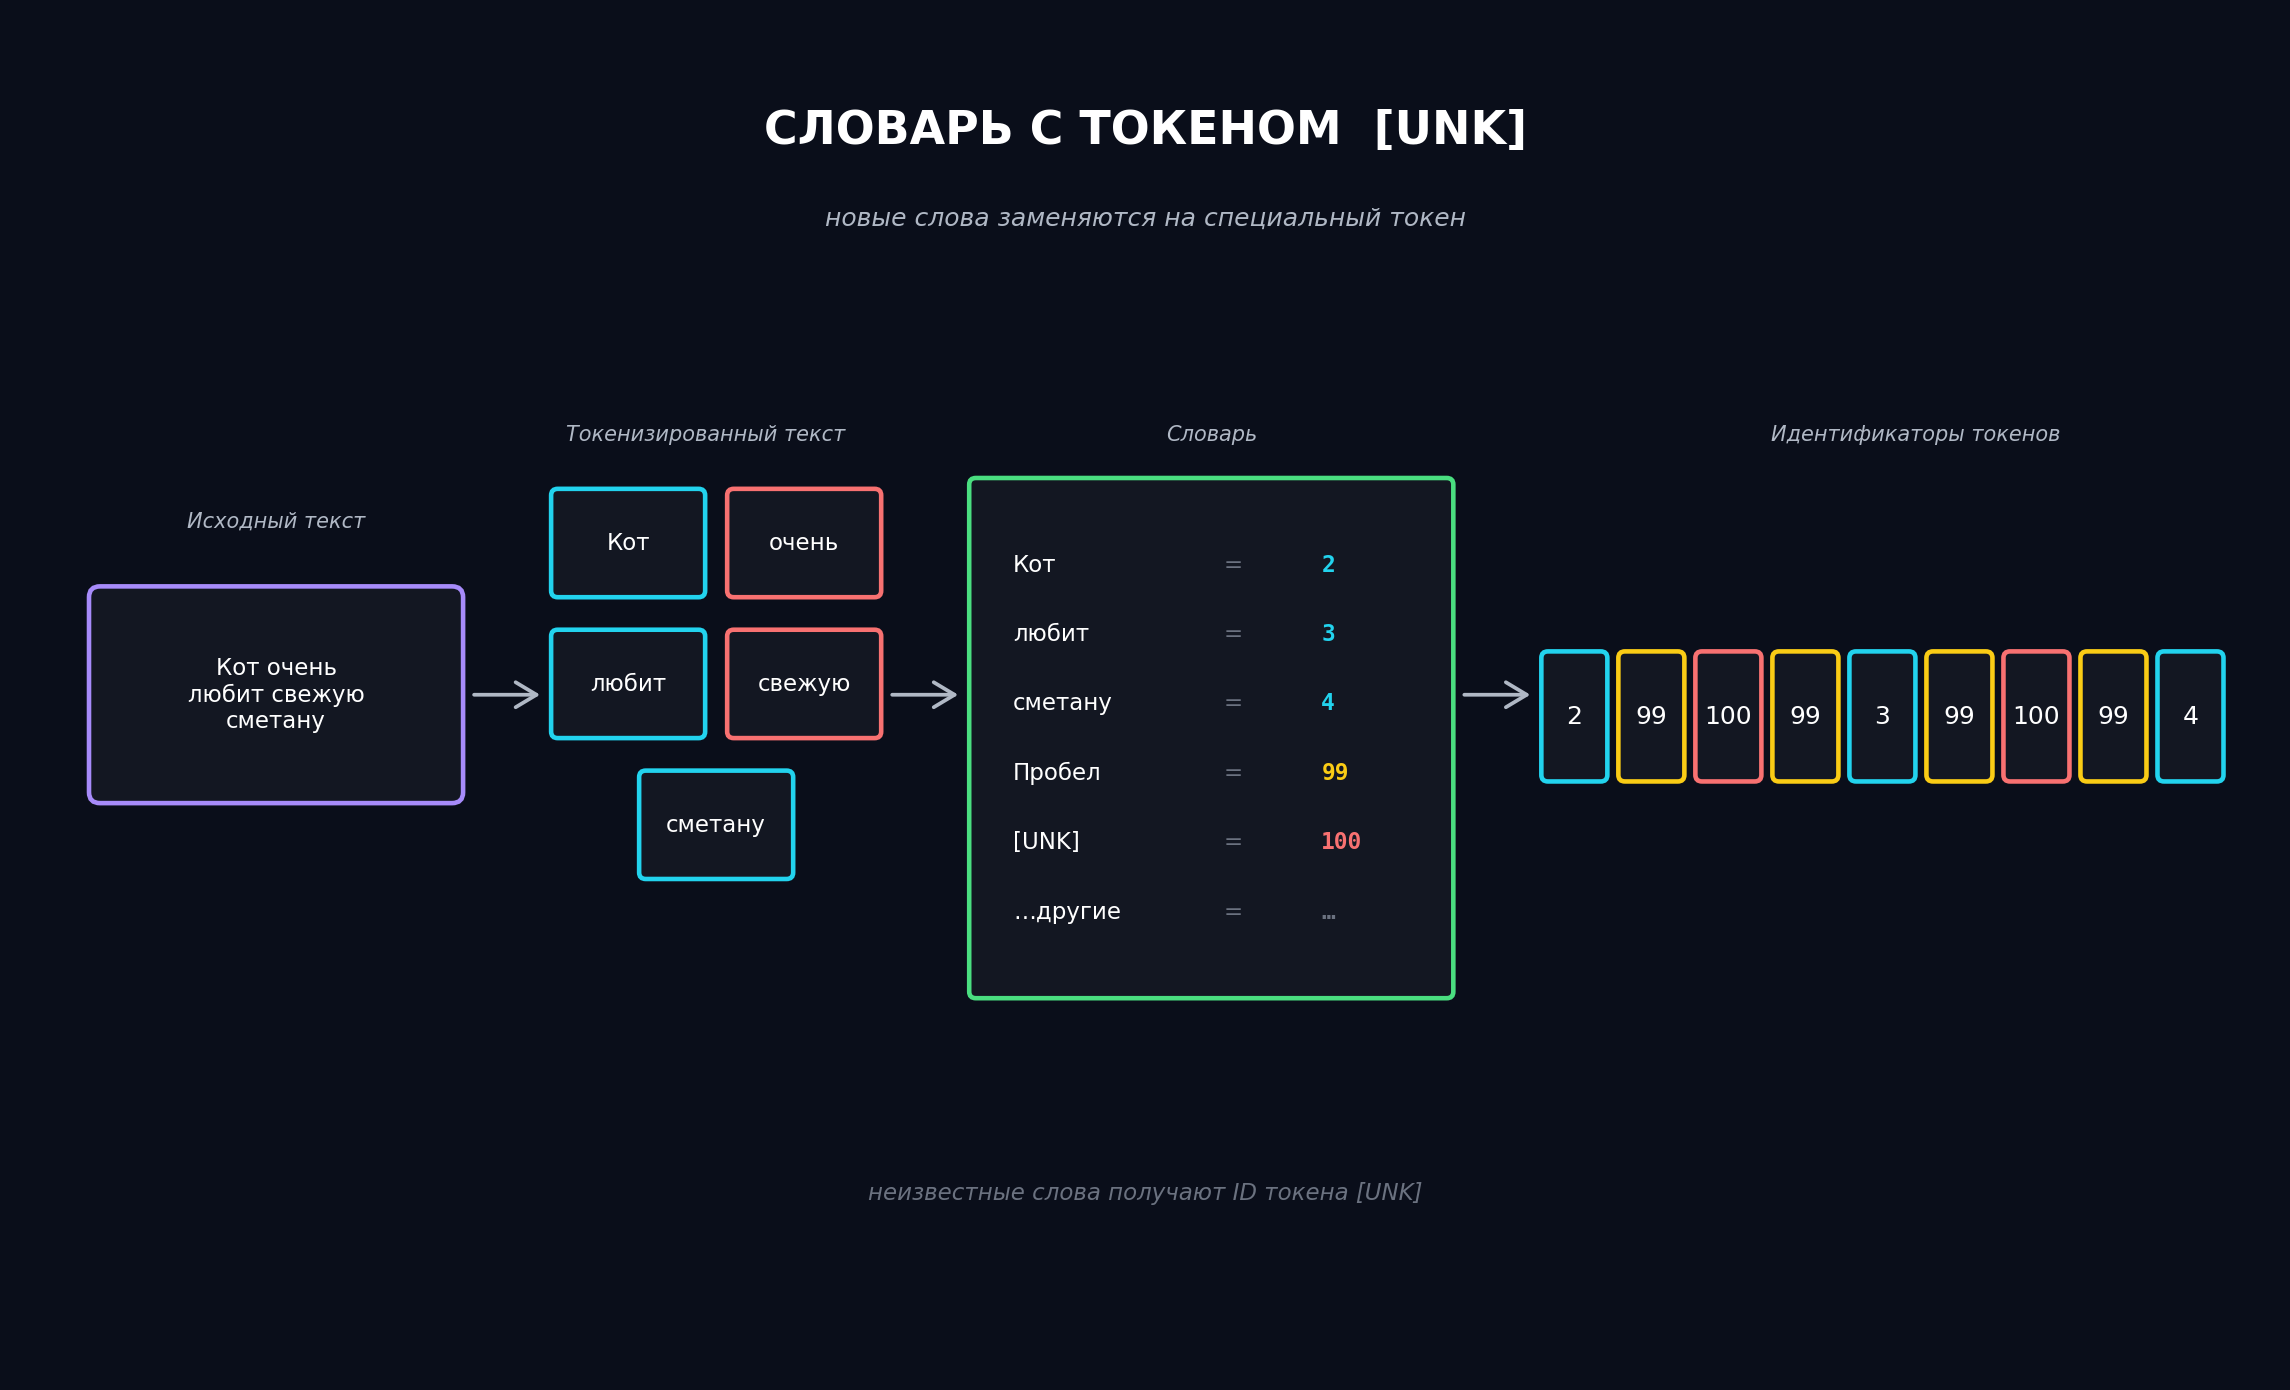

## Детокенизация - пытаемся из идентификаторов получить предложение.

Обратный процесс - детокенизация - это превращение последовательности ID обратно в текст. Если у нас есть словарь, в котором каждому ID соответствует токен, то мы просто заменяем каждый ID на соответствующий токен и объединяем их.

Используя наш словарь, преобразуем ID токенов в предложение:

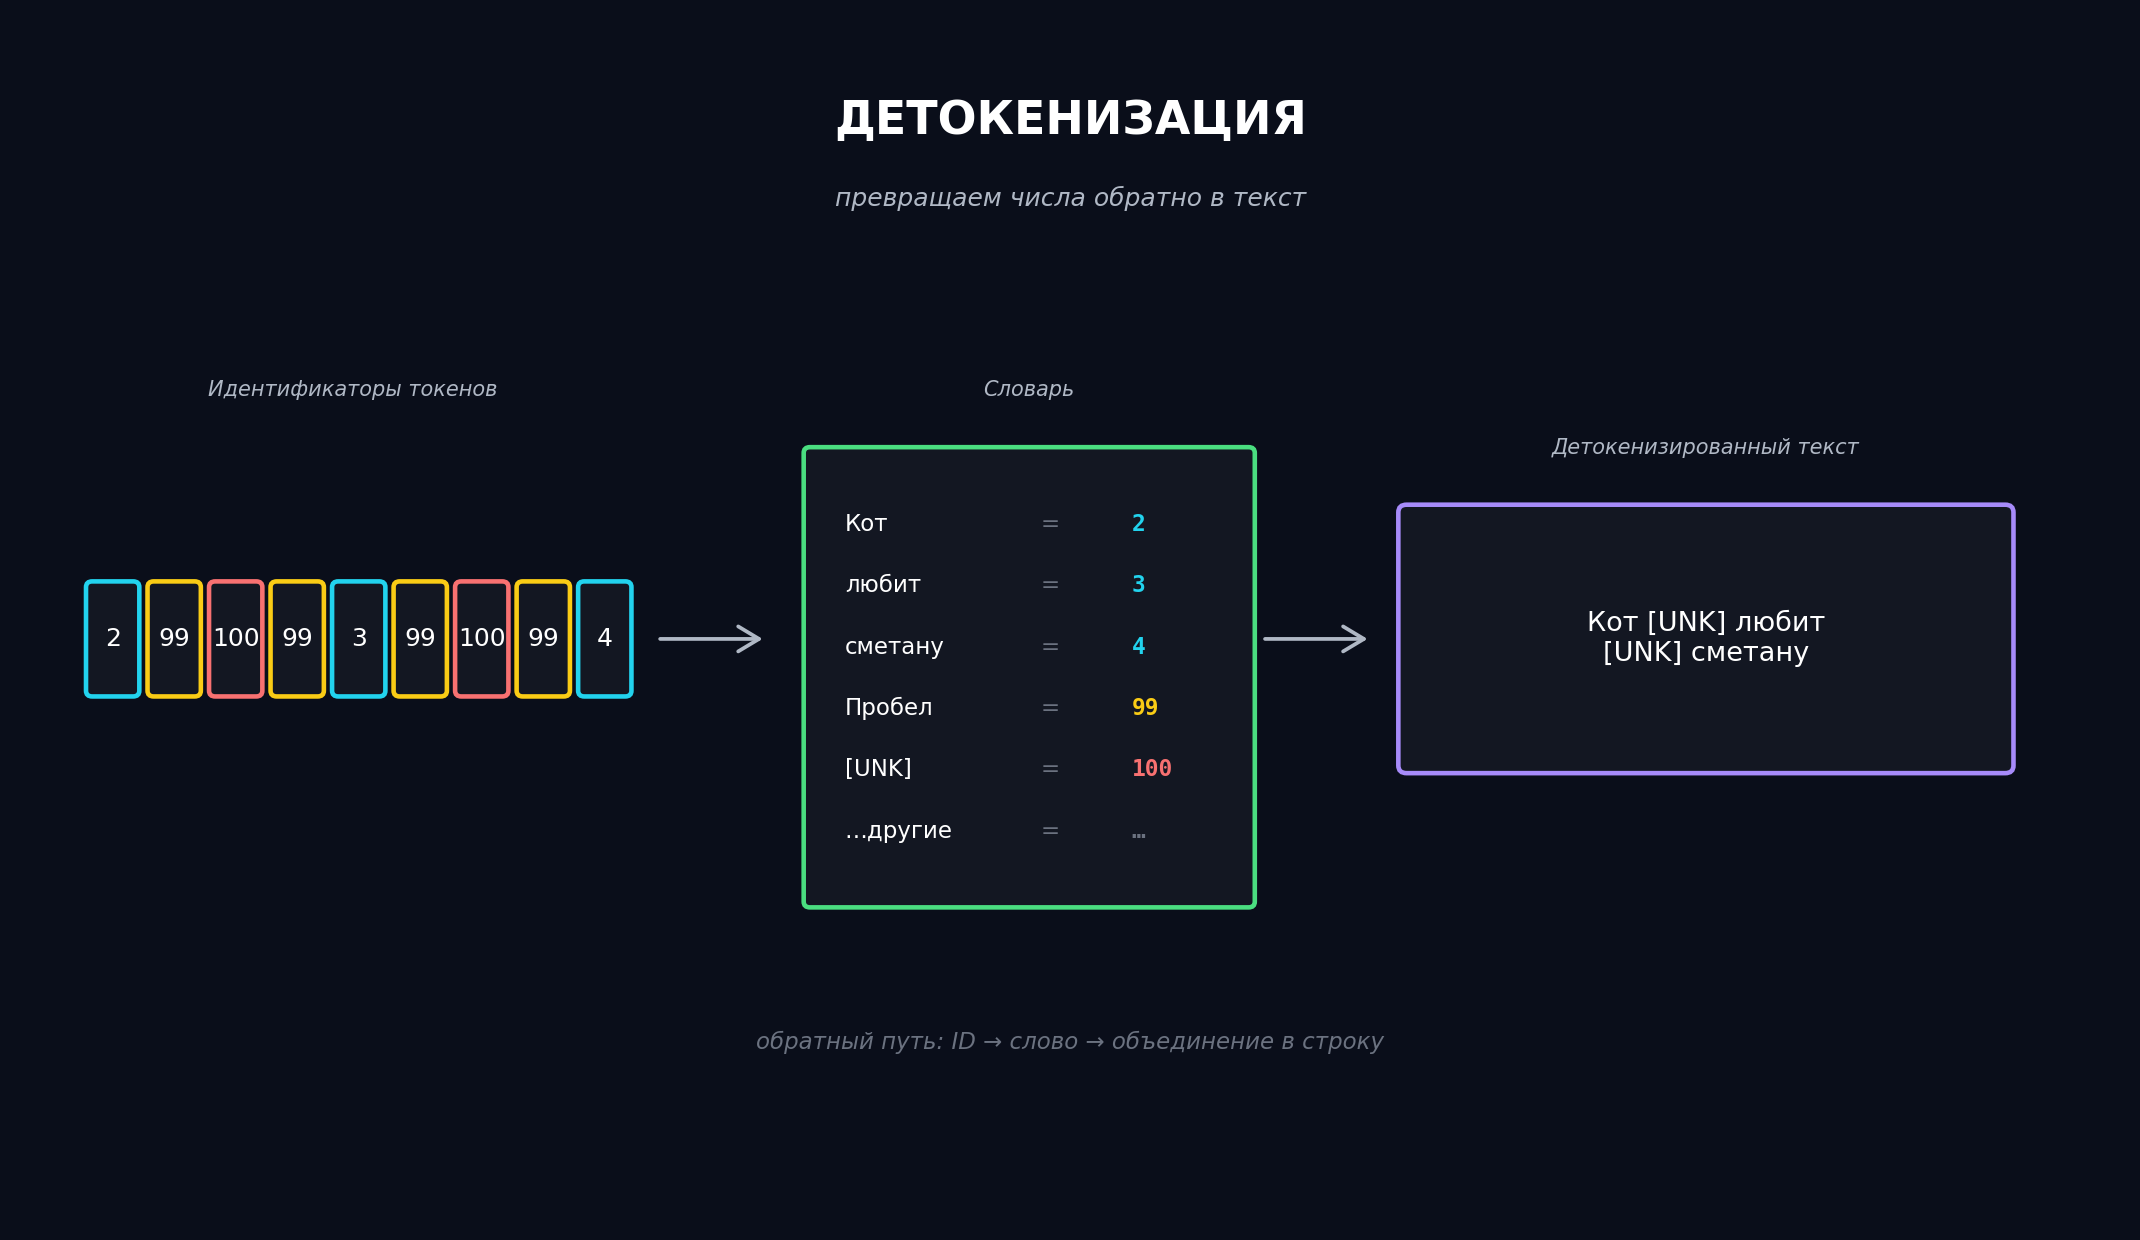

Возникает вопрос, а что сделать с [UNK] в результирующем тексте. Далее, мы попробуем решить данную проблему.

## Токенизация/Детокенизация на подслова (BPE)

Итак, мы уперлись в потолок. Слова `«очень»` и `«свежую»` наш словарь не знает. И при детокенизации, мы теряем часть предложения. Для русского языка, где у каждого слова есть окончания, падежи и времена, словарный подход крайне не эффективен. Нам пришлось бы запомнить миллионы форм слов, чтобы покрыть хоть сколько-нибудь живой текст.

Здесь на сцену выходит компромисс, который используют почти все современные модели, включая GPT. Мы перестаем делить текст на целые слова. Вместо этого мы делим его на **подслова (subwords)**.

**BPE (Byte Pair Encoding)** - это популярный алгоритм токенизации, который разбивает текст на единицы меньше слова, но больше символа (так называемые подслова или subwords).

Представьте, что вы собираете конструктор Lego. У вас нет готовой детали «Замок». У вас есть кирпичики «Стена», «Башня», «Флаг». Из них можно собрать любой замок, даже тот, которого вы раньше не видели. Так же работает и BPE. У нас нет готового токена «сметану», но есть кусочки «смет» и «ану». Модель видит части слова по отдельности и может узнавать их в других словах. При этом BPE режет слова не по морфологии - это просто статистически удобные склейки.



Алгоритм BPE не придумывает правила грамматики. Он действует чисто статистически. Вот его логика:

1. Сначала мы разбиваем все слова на символы. Слово «кот» превращается в `['к', 'о', 'т']`.
2. Мы считаем, какие пары символов встречаются в текстах чаще всего.
3. Самую частую пару мы объединяем в новый токен.
4. Повторяем это снова и снова, пока не наберем нужный размер словаря.

В итоге самые частые сочетания букв становятся отдельными токенами. Суффиксы, приставки, популярные корни - все это становится «кирпичиками». Редкие слова собираются из редких кирпичиков, но они всё равно состоят из знакомых модели элементов. Проблема OOV (неизвестных слов) исчезает, потому что любое слово можно разложить на буквы, а буквы у нас есть всегда.

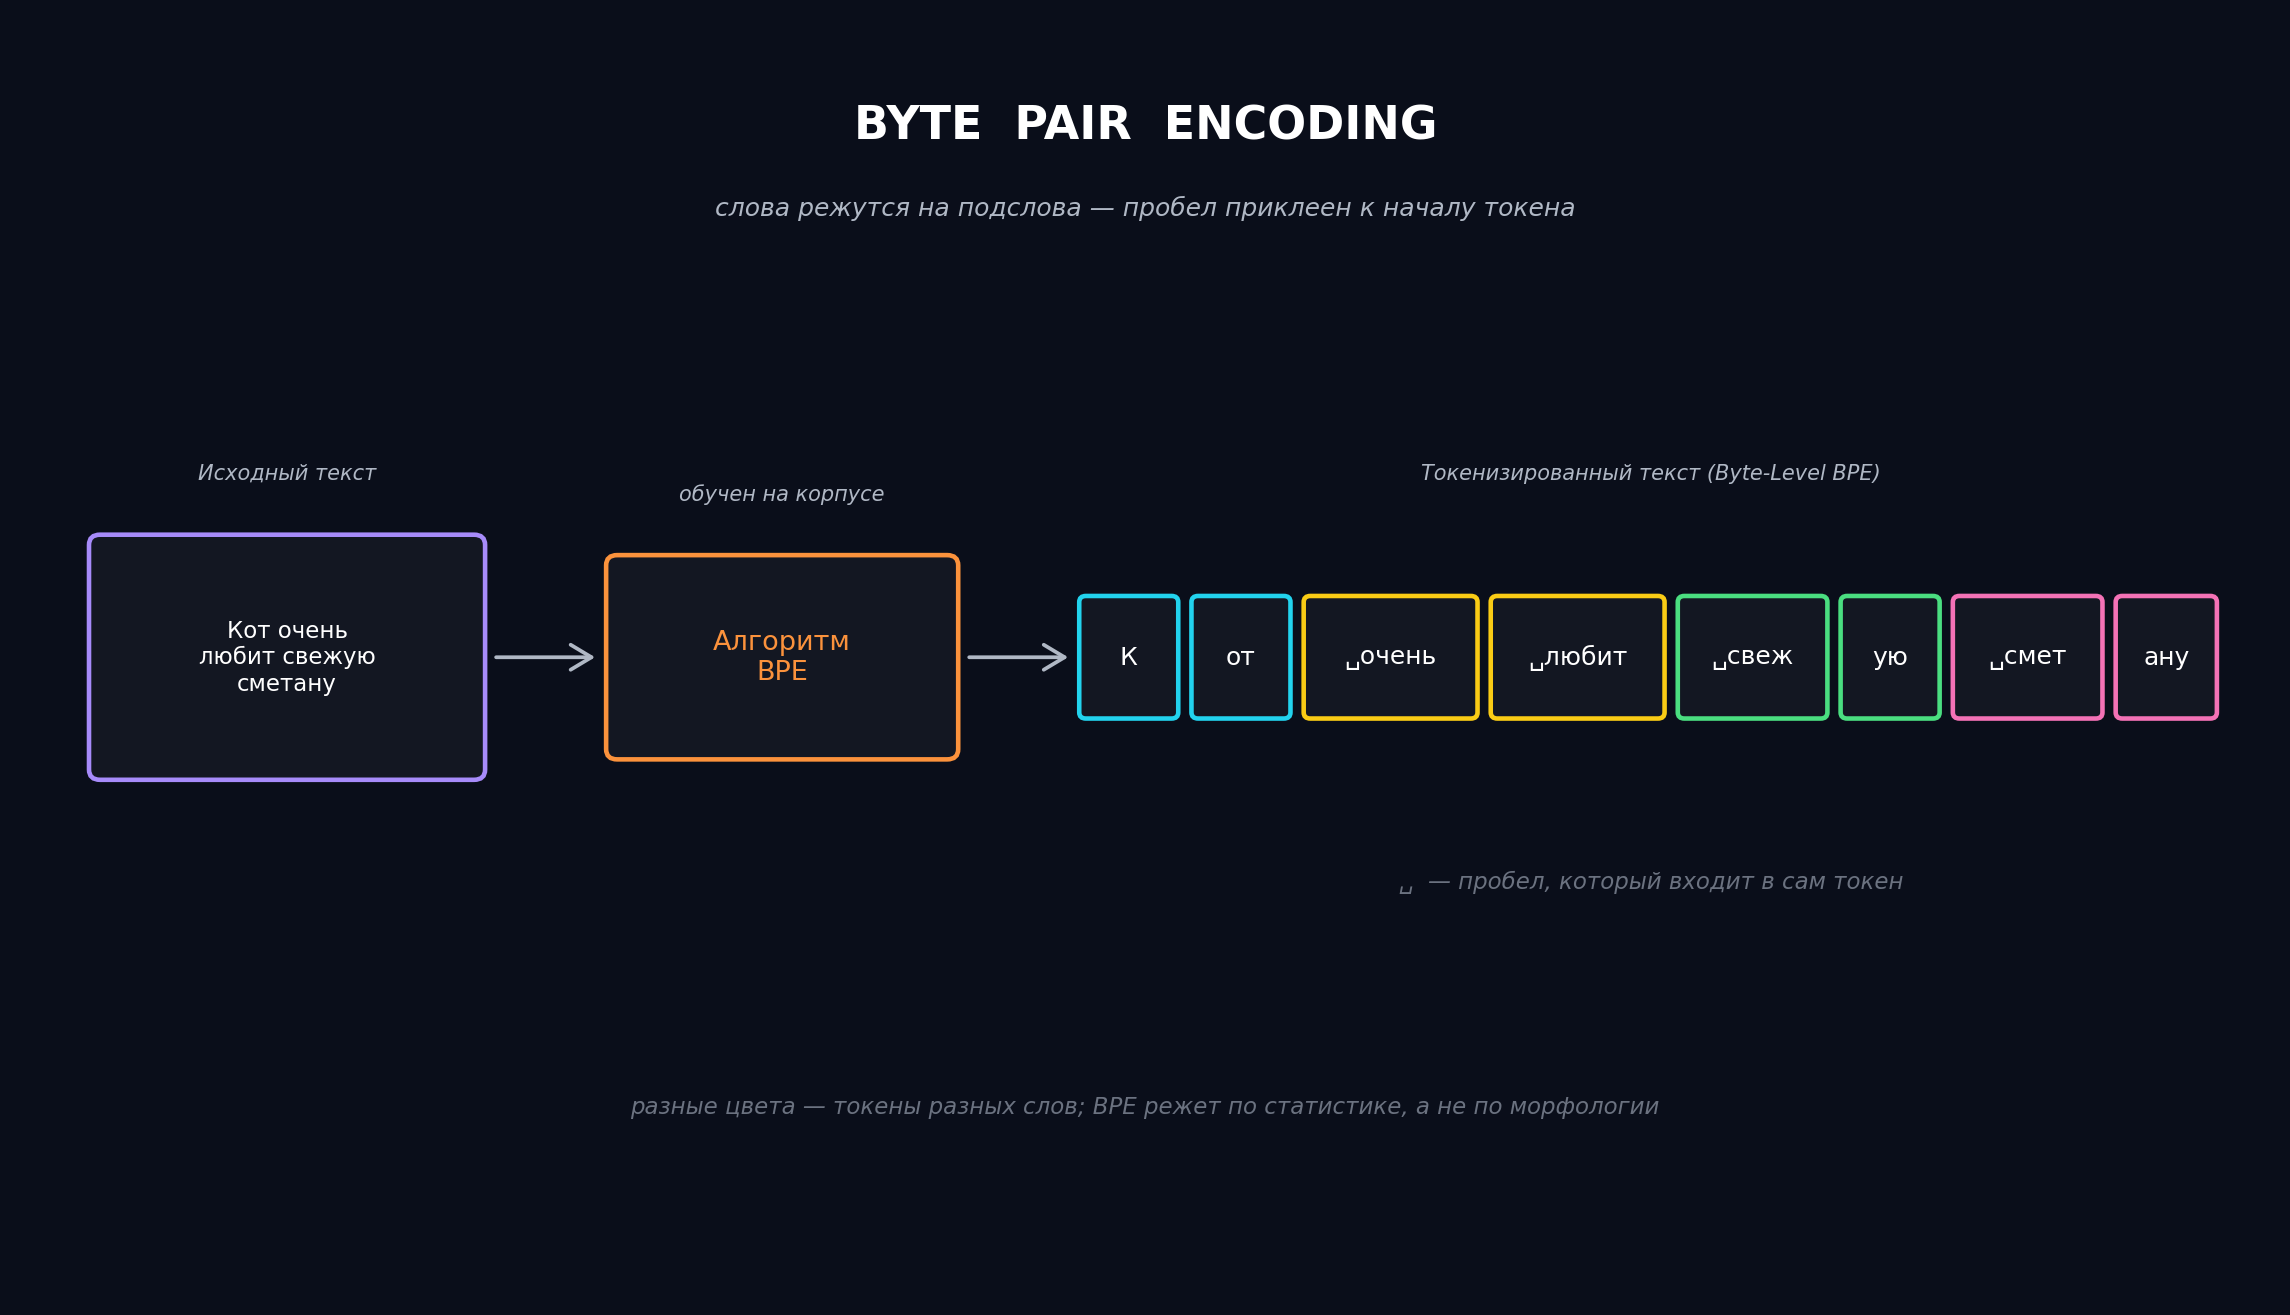

Обратите внимание, на новые токены:

- Слово «Кот» разбилось на два подслова: К и от. Токенизатор решил, что заглавная «К» в начале предложения - отдельный кусочек.
- «очень» и «любит» - остались целыми, потому что это частые слова, которые BPE запомнил целиком.
- Слово «свежую» разбилось на свеж и ую. Корень «свеж» встречается часто, а окончание «ую» - отдельный кусочек, который может появляться после разных основ (свежую, большую, красную...).
- Слово «сметану» разбилось на смет и ану.
- Пробел перед словом входит в сам токен (например, очень - с пробелом впереди). Это особенность Byte-Level BPE: пробел не является отдельным токеном, а «приклеивается» к началу следующего слова. BPE режет не по правилам грамматики, а по статистике.

Далее, с помощью специального словаря, который использует токенизатор BPE, уже просто переводим в идентификаторы токенов. Таким образом, всю работу берет на себя токенизатор BPE, в нем почти невозможно получить токен [UNK], так как любое незнакомое слово BPE разберет по буквам и найдет соответствующий идентификатор.

BPE позволяет балансировать между размером словаря и покрытием. Он гарантирует, что любое слово можно представить как последовательность подслов (в худшем случае - как отдельные символы), поэтому проблема OOV практически исчезает. Современные GPT-модели используют именно такую токенизацию - BPE. (У BERT токенизатор другой, WordPiece, но принцип подслов тот же.)

*Примечание: Существуют и другие алгоритмы подсловной токенизации, например WordPiece (используется в BERT) и Unigram (используется в T5). Принцип у них похожий - разбивать текст на подслова, - но детали построения словаря отличаются. В нашем курсе мы работаем с BPE, так как именно он лежит в основе GPT-архитектуры, которую мы строим.*

## Пишем простой токенизатор

Попробуем реализовать наш пример:

`Кот очень любит свежую сметану`

Разобьём исходный текст на слова с помощью split(). Однако split() разделяет по пробелам, оставляя знаки препинания прикреплёнными к словам. Можно дополнительно отделить знаки препинания регулярными выражениями или просто использовать готовые токенизаторы из библиотек. Но наша задача - понять саму суть, а не нюансы.

Реализовано в `simple_tokens.py`

Рассмотрим упрощённую реализацию алгоритма Byte Pair Encoding (BPE) на Python

Предположим, у нас есть корпус слов с частотами:

In [20]:
from collections import Counter

corpus = ["Привет", "мир", "Приветик", "мирный"]
# Разобьём каждое слово на символы и добавим специальный символ конца слова (</w>)
word_freqs = Counter(corpus)

vocab = {}
for word in word_freqs:
    # начальное разбиение на символы + символ конца слова
    vocab[word] = list(word) + ['</w>']

print("Начальный словарь подслов (каждое слово как список символов):")
for word, chars in vocab.items():
    print(f"{word}: {chars}")

Начальный словарь подслов (каждое слово как список символов):
Привет: ['П', 'р', 'и', 'в', 'е', 'т', '</w>']
мир: ['м', 'и', 'р', '</w>']
Приветик: ['П', 'р', 'и', 'в', 'е', 'т', 'и', 'к', '</w>']
мирный: ['м', 'и', 'р', 'н', 'ы', 'й', '</w>']


Теперь будем искать самую частую пару символов и объединять её. Для этого нужно посчитать частоты всех пар во всех словах с учётом частот слов.

In [21]:
def get_stats(vocab):
    pairs = Counter()
    for word, symbols in vocab.items():
        freq = word_freqs[word]
        for i in range(len(symbols)-1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    new_vocab = {}
    bigram = ' '.join(pair)  # склеим в строку для замены
    replacement = ''.join(pair)
    for word, symbols in vocab.items():
        # преобразуем список символов в строку с пробелами для удобства замены
        word_str = ' '.join(symbols)
        word_str = word_str.replace(bigram, replacement)
        new_vocab[word] = word_str.split()
    return new_vocab

# Обучим несколько итераций BPE
num_merges = 10
for i in range(num_merges):
    stats = get_stats(vocab)
    if not stats:
        break
    most_frequent = max(stats, key=stats.get)
    print(f"Шаг {i+1}: объединяем пару {most_frequent}")
    vocab = merge_vocab(most_frequent, vocab)

print("\nИтоговое разбиение:")
for word, chars in vocab.items():
    print(f"{word}: {chars}")

Шаг 1: объединяем пару ('П', 'р')
Шаг 2: объединяем пару ('Пр', 'и')
Шаг 3: объединяем пару ('При', 'в')
Шаг 4: объединяем пару ('Прив', 'е')
Шаг 5: объединяем пару ('Приве', 'т')
Шаг 6: объединяем пару ('м', 'и')
Шаг 7: объединяем пару ('ми', 'р')
Шаг 8: объединяем пару ('Привет', '</w>')
Шаг 9: объединяем пару ('мир', '</w>')
Шаг 10: объединяем пару ('Привет', 'и')

Итоговое разбиение:
Привет: ['Привет</w>']
мир: ['мир</w>']
Приветик: ['Привети', 'к', '</w>']
мирный: ['мир', 'н', 'ы', 'й', '</w>']


Слово **корпус** происходит от латинского corpus - «тело», «целостный объект». В современной лингвистике корпус - это большой, обычно машиночитаемый, структурированный набор текстов (или устных записей), собранных по определённым принципам. Корпус может быть:

- Одного языка (например, Национальный корпус русского языка).

- Сбалансированным (содержать тексты разных жанров, эпох, стилей в пропорциях, отражающих реальное употребление языка).

- Аннотированным (размеченным: слова могут быть помечены частями речи, синтаксическими связями, эмоциональной окраской и т.д.).

В компьютерной лингвистике и NLP (Natural Language Processing) корпус - это просто набор текстовых данных, на котором мы обучаем модели, проверяем гипотезы или строим словари. Он может быть совсем маленьким (как наш пример из четырёх слов) или гигантским (терабайты текстов из интернета).

После нескольких итераций мы получим словарь подслов, содержащий как отдельные буквы, так и их сочетания. Теперь любое слово можно разбить на подслова, проходя по словарю (жадный алгоритм - выбираем самое длинное подслово из начала строки и т.д.). Это уже сложнее, но суть понятна.

**Писать алгоритм BPE каждый раз - не лучшее решение.**

Это не только неэффективно, но и не имеет смысла. Важно понять, как он работает. На практике обычно используют готовую библиотеку `transformers`, в которой BPE уже встроен. Проще всего взять уже обученный токенизатор для русского языка, например от модели **ai-forever/rugpt3small_based_on_gpt2**. Это русская GPT-модель, и её токенизатор основан именно на BPE - том самом алгоритме, который мы только что разобрали. Библиотека `transformers` позволяет легко загружать предобученные токенизаторы вместе с моделями.

Реализовано в `tokenizer_bpe.py`

Полученный вывод:
`Токены: ['К', 'от', ' очень', ' любит', ' свеж', 'ую', ' смет', 'ану']
ID: [684, 370, 939, 7281, 9162, 516, 23913, 5123]`

**Обратите внимание:** пробел перед словом входит в сам токен (например, очень начинается с пробела). Это особенность Byte-Level BPE, который используется в GPT-моделях. Пробел не является отдельным токеном, а «приклеивается» к началу следующего слова.